# Improved Finetuning for Fox Classification
## Real-Time Detection on Raspberry Pi

This notebook takes the original idea in the `pretrained_model.py` script and aims to finetune the model on images sourced from cameras placed around campus. Below are the various sections explaining methodology and process:

| Section # | |
|---|---|
| 1 | Imports |
| 2 | Data Loading |
| 3 | Class-Weighted Loss |
| 4 | Model: MobileNetV2 |
| 5 | Training Helpers |
| 6 | Two-Phase Finetuning |
| 7 | Learning Curves |
| 8 | Evaluation |

**Dataset stats:**
- `data/camera_images/train/` — foxes: 157, possum: 14, raccoon: 7
- `data/camera_images/val/`   — foxes: 65,  possum: 6,  raccoon: 3
- Foxes are ~88% of the training data. Raccoon and possum are the rare classes.
- With only 10 total raccoon images, a held-out test set is not viable — a 3-way split would leave 1–2 raccoon samples in val and test, making metrics meaningless. We use the existing train/val split.


## 1. Imports

In [13]:
import copy
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import torchvision
from torchvision import datasets, transforms
from torchvision.models import MobileNet_V2_Weights

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Data Loading

The data is already split into `train/` and `val/` subdirectories, each containing class folders (`foxes/`, `possum/`, `raccoon/`). We load them as separate `ImageFolder` datasets so each gets its own transform.

**Augmentation choices:**
- `ColorJitter` — camera trap images vary widely between day/night and season
- `RandomRotation` + `RandomPerspective` — animals move through the frame at different angles
- These are applied to training only; validation uses a clean center crop for reproducible metrics

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomRotation(15),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

data_dir = 'data/camera_images'
train_set = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=train_transform)
val_set = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=eval_transform)

class_names = train_set.classes
assert class_names == val_set.classes, "Train and val class lists don't match!"

print(f"Classes: {class_names}")
print(f"Train class distribution: {Counter(train_set.targets)}")
print(f"Val class distribution: {Counter(val_set.targets)}")
print(f"(class indices: {{name: i for i, name in enumerate(class_names)}})")

NUM_WORKERS = min(4, os.cpu_count())
train_loader = torch.utils.data.DataLoader(train_set, batch_size=16, shuffle=True, num_workers=NUM_WORKERS)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=16, shuffle=False, num_workers=NUM_WORKERS)

print(f"\nTrain batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Classes: ['foxes', 'possum', 'raccoon']
Train class distribution: Counter({0: 157, 1: 14, 2: 7})
Val class distribution:   Counter({0: 65, 1: 6, 2: 3})
  (class indices: {'foxes': 0, 'possum': 1, 'raccoon': 2})

Train batches: 12, Val batches: 5


## 3. Class-Weighted Loss

**Why?** Foxes make up ~88% of training images. A model that predicts fox every time gets 88% accuracy without learning anything useful. Class weighting penalizes the model more heavily for missing the rare classes (raccoon, possum), so it must actually learn to distinguish them.

Implications: the vaccine dispenser needs **high fox recall** (don't miss a fox) but also **high possum/raccoon precision** (don't dispense to non-foxes). Per-class metrics in Section 8 will surface this tradeoff directly.

In [ ]:
train_labels = train_set.targets
class_counts = Counter(train_labels)
n_samples = len(train_labels)
n_classes = len(class_names)

# Inverse-frequency weighting: rarer classes get higher weight
class_weights = torch.tensor(
    [n_samples / (n_classes * class_counts[c]) for c in range(n_classes)],
    dtype=torch.float32).to(device)

print("Class weights (higher = rarer class, penalised more for misclassification):")
for name, count, w in zip(class_names, [class_counts[c] for c in range(n_classes)], class_weights):
    print(f"{name:<10}  n={count:>3}   weight={w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

Class weights (higher = rarer class, penalised more for misclassification):
  foxes       n=157   weight=0.378
  possum      n= 14   weight=4.238
  raccoon     n=  7   weight=8.476


## 4. Model: MobileNetV2

In [ ]:
def build_model(num_classes, freeze_backbone=True):
    """
    Load pretrained MobileNetV2 and replace the classifier head.
    
    freeze_backbone=True  → only the new head is trainable (Phase 1)
    freeze_backbone=False → all parameters trainable (Phase 2)
    """
    model = torchvision.models.mobilenet_v2(
        weights=MobileNet_V2_Weights.IMAGENET1K_V1
    )

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # MobileNetV2's classifier[-1] has in_features=1280
    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes),
    )

    return model.to(device)

model = build_model(num_classes=n_classes, freeze_backbone=True)

n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {n_trainable:,} / {n_total:,}")

Trainable params: 3,843 / 2,227,715


## 5. Training Helpers

**Early stopping** halts training when validation loss stops improving. With only ~178 training images, overfitting can kick in unpredictably. Early stopping is more dynamic than picking a fixed epoch count.

In [ ]:
class EarlyStopping:
    """Stop training when val_loss doesn't improve for `patience` epochs."""
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def run_epoch(model, loader, criterion, optimizer=None):
    """One pass through `loader`. Trains if optimizer is given, else evaluates."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, total_correct = 0.0, 0

    with torch.set_grad_enabled(training):
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * inputs.size(0)
            total_correct += (outputs.argmax(1) == targets).sum().item()

    n = len(loader.dataset)
    return total_loss / n, total_correct / n


def train(model, train_loader, val_loader, criterion, optimizer, scheduler,
          max_epochs=30, patience=5, label=''):
    """Full training loop with early stopping. Returns loss/accuracy history."""
    stopper = EarlyStopping(patience=patience)
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"\n{'─'*60}")
    print(f" {label}")
    print(f"{'─'*60}")

    for epoch in range(max_epochs):
        t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = run_epoch(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_acc:
            best_acc = v_acc
            best_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1:>2}/{max_epochs} | "
              f"train loss {t_loss:.4f} acc {t_acc:.3f} | "
              f"val loss {v_loss:.4f} acc {v_acc:.3f}")

        if stopper.step(v_loss):
            print(f"Early stop at epoch {epoch+1} (patience={patience} exceeded)")
            break

    print(f"Best val acc: {best_acc:.4f}")
    model.load_state_dict(best_wts)
    return history

print("Utilities defined.")

Utilities defined.


## 6. Two-Phase Finetuning

**Why two phases?**

Finetuning all layers from epoch 0 risks overwriting well-learned ImageNet features before the new head has stabilised. Large gradients from the randomly-initialised head propagate all the way back through the backbone.

**Phase 1** — freeze backbone, train only the 3-class head at LR=1e-3. The head converges in a few epochs; gradients are small by the time we unfreeze.

**Phase 2** — unfreeze backbone with differential learning rates: backbone at 1e-4 (gentle nudge), head at 1e-3 (normal). This lets the backbone adapt without forgetting everything.

In [ ]:
# Phase 1: Train head only

optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)
scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p1, T_max=10)

history_p1 = train(
    model, train_loader, val_loader, criterion,
    optimizer_p1, scheduler_p1,
    max_epochs=10, patience=4,
    label='Phase 1: Head only'
)


────────────────────────────────────────────────────────────
 Phase 1: Head only
────────────────────────────────────────────────────────────
Epoch  1/10 | train loss 1.3264 acc 0.517 | val loss 1.1607 acc 0.176
Epoch  2/10 | train loss 1.3557 acc 0.438 | val loss 0.4997 acc 0.865
Epoch  3/10 | train loss 1.0380 acc 0.775 | val loss 0.5791 acc 0.878
Epoch  4/10 | train loss 0.9569 acc 0.680 | val loss 0.6906 acc 0.824
Epoch  5/10 | train loss 0.8890 acc 0.629 | val loss 0.4994 acc 0.824
Epoch  6/10 | train loss 0.8384 acc 0.865 | val loss 0.4191 acc 0.892
Epoch  7/10 | train loss 0.8242 acc 0.837 | val loss 0.5054 acc 0.851
Epoch  8/10 | train loss 0.8580 acc 0.719 | val loss 0.5534 acc 0.851
Epoch  9/10 | train loss 0.8843 acc 0.725 | val loss 0.5394 acc 0.838
Epoch 10/10 | train loss 0.7991 acc 0.736 | val loss 0.5454 acc 0.851
Early stop at epoch 10 (patience=4 exceeded)
Best val acc: 0.8919


In [ ]:
# Phase 2: Unfreeze backbone

for param in model.features.parameters():
    param.requires_grad = True

optimizer_p2 = optim.SGD([
    {'params': model.features.parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
], momentum=0.9, weight_decay=1e-4)

scheduler_p2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_p2, T_max=20)

history_p2 = train(
    model, train_loader, val_loader, criterion,
    optimizer_p2, scheduler_p2,
    max_epochs=20, patience=6,
    label='Phase 2: Full model (backbone LR=1e-4, head LR=1e-3)'
)


────────────────────────────────────────────────────────────
 Phase 2: Full model (backbone LR=1e-4, head LR=1e-3)
────────────────────────────────────────────────────────────
Epoch  1/20 | train loss 0.8649 acc 0.725 | val loss 0.5308 acc 0.811
Epoch  2/20 | train loss 1.0129 acc 0.775 | val loss 0.5751 acc 0.838
Epoch  3/20 | train loss 0.8374 acc 0.708 | val loss 0.6085 acc 0.757
Epoch  4/20 | train loss 0.7480 acc 0.691 | val loss 0.4154 acc 0.878
Epoch  5/20 | train loss 0.6058 acc 0.747 | val loss 0.3306 acc 0.919
Epoch  6/20 | train loss 0.5538 acc 0.708 | val loss 0.4407 acc 0.811
Epoch  7/20 | train loss 0.6904 acc 0.809 | val loss 0.3823 acc 0.865
Epoch  8/20 | train loss 0.5104 acc 0.826 | val loss 0.3466 acc 0.892
Epoch  9/20 | train loss 0.6395 acc 0.702 | val loss 0.4258 acc 0.838
Epoch 10/20 | train loss 0.5318 acc 0.803 | val loss 0.3469 acc 0.892
Epoch 11/20 | train loss 0.5271 acc 0.764 | val loss 0.4501 acc 0.851
Early stop at epoch 11 (patience=6 exceeded)
Best val

## 7. Learning Curves

The plots show training and validation loss/accuracy across both phases, with a vertical dashed line marking where Phase 2 begins.

**Ideal signs:**
- In Phase 1, validation loss should drop quickly — the head is learning fast from frozen ImageNet features
- At the Phase 2 boundary, there may be a small bump in loss as the backbone begins updating
- A healthy run has train and val curves tracking closely together. If train loss keeps falling while val loss flattens or rises, that's overfitting — with only 178 training images this is likely
- Early stopping will have already cut training off at the right point, so the curves should end before the gap between train and val becomes large

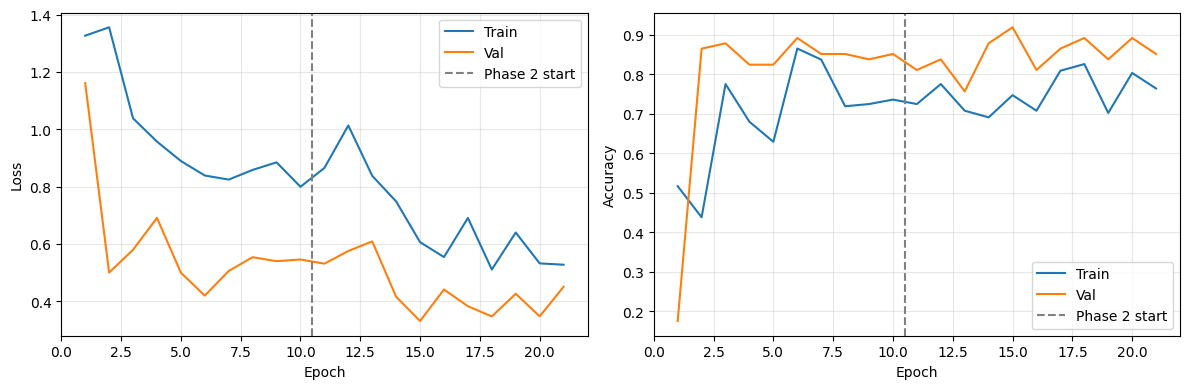

In [ ]:
def plot_history(h1, h2):
    train_loss = h1['train_loss'] + h2['train_loss']
    val_loss = h1['val_loss'] + h2['val_loss']
    train_acc = h1['train_acc'] + h2['train_acc']
    val_acc = h1['val_acc'] + h2['val_acc']
    p1_end = len(h1['train_loss'])

    epochs = range(1, len(train_loss) + 1)
    fig,(ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    for ax, tr, vl, ylabel in [
        (ax1, train_loss, val_loss, 'Loss'),
        (ax2, train_acc, val_acc, 'Accuracy'),
    ]:
        ax.plot(epochs, tr, label='Train')
        ax.plot(epochs, vl, label='Val')
        ax.axvline(p1_end + 0.5, color='gray', linestyle='--', label='Phase 2 start')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_p1, history_p2)

## 8. Evaluation: Per-Class Metrics + Confusion Matrix

**Why not just accuracy?**

Given that foxes are ~88% of the data, a model that always predicts fox gets ~88% accuracy without learning anything. The metrics that matter for this project are:

- **Fox recall** — of all actual foxes, how many did we correctly trigger the dispenser for?
- **Possum/raccoon precision** — of all dispenser triggers, how many were foxes (not wasted biscuits)?

The confusion matrix shows which classes are being confused.


Validation Results
              precision    recall  f1-score   support

       foxes      0.968     0.938     0.953        65
      possum      0.667     1.000     0.800         6
     raccoon      0.500     0.333     0.400         3

    accuracy                          0.919        74
   macro avg      0.712     0.757     0.718        74
weighted avg      0.925     0.919     0.918        74



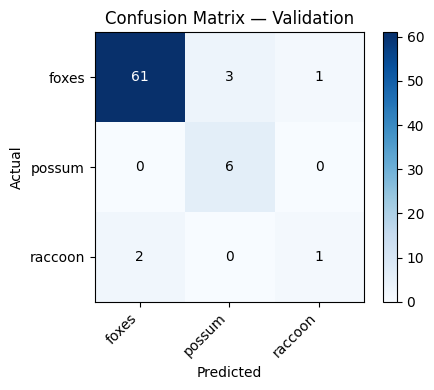

In [21]:
def evaluate(model, loader, class_names, split_name='Val'):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs.to(device))
            preds   = outputs.argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(targets.numpy())

    print(f"\n{split_name} Results")
    print('=' * 50)
    print(classification_report(
        all_labels, all_preds, target_names=class_names, digits=3
    ))

    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {split_name}')
    plt.colorbar(im, ax=ax)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    plt.tight_layout()
    plt.show()

evaluate(model, val_loader, class_names, 'Validation')

### Fundamental limitation

With only 10 raccoon and 20 possum images, the minority class metrics will have high variance regardless of any training improvements. The highest-leverage next step is data collection:

1. **More camera trap images** from the same campus location (same lighting, angle, background)
2. **iNaturalist / GBIF** — thousands of labeled wildlife images available via API
3. **Domain adaptation** — pre-finetune on a large wildlife dataset (iWildCam, WCS Camera Traps) before adapting to campus images
